<a href="https://colab.research.google.com/github/Tuanyatuanya/MSSP607/blob/main/Case_Study_Report_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
from google.colab import drive
drive.mount('/content/drive')
!git clone https://github.com/tuanyatuanya/MSSP607.git

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'MSSP607' already exists and is not an empty directory.


In [68]:
df = pd.read_csv('/content/drive/MyDrive/MSSP607/Modules/Week_7 folder/InternetSales.csv', encoding = 'latin-1')

/tmp/ipython-input-3450668934.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/MSSP607/Modules/Week_7 folder/InternetSales.csv', encoding = 'latin-1')


In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [70]:
df.head()

,ID,CustomerKey,GeographyKey,City,CountryRegionCode,EnglishCountryRegionName,CustomerAlternateKey,Title,FirstName,MiddleName,...,ProductStandardCost,TotalProductCost,SalesAmount,TaxAmt,Freight,CarrierTrackingNumber,CustomerPONumber,OrderDate,DueDate,ShipDate
0,0,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1912.1544,1912.1544,3399.99,271.9992,84.9998,NaN,NaN,1/19/2011,1/31/2011,1/26/2011
1,1,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1265.6195,1265.6195,2319.99,185.5992,57.9998,NaN,NaN,1/18/2013,1/30/2013,1/25/2013
2,2,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,8.2205,8.2205,21.98,1.7584,0.5495,NaN,NaN,1/18/2013,1/30/2013,1/25/2013
3,3,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1481.9379,1481.9379,2384.07,190.7256,59.6018,NaN,NaN,5/3/2013,5/15/2013,5/10/2013
4,4,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,10.8423,10.8423,28.99,2.3192,0.7248,NaN,NaN,5/3/2013,5/15/2013,5/10/2013


In [71]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60398 entries, 0 to 60397
Data columns (total 60 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        60398 non-null  int64  
 1   CustomerKey               60398 non-null  int64  
 2   GeographyKey              60398 non-null  int64  
 3   City                      60398 non-null  object 
 4   CountryRegionCode         60398 non-null  object 
 5   EnglishCountryRegionName  60398 non-null  object 
 6   CustomerAlternateKey      60398 non-null  object 
 7   Title                     307 non-null    object 
 8   FirstName                 60398 non-null  object 
 9   MiddleName                34903 non-null  object 
 10  LastName                  60398 non-null  object 
 11  NameStyle                 60398 non-null  bool   
 12  BirthDate                 60398 non-null  object 
 13  MaritalStatus             60398 non-null  object 
 14  Suffix

,ID,CustomerKey,GeographyKey,YearlyIncome,TotalChildren,NumberChildrenAtHome,HouseOwnerFlag,NumberCarsOwned,ProductKey,OrderDateKey,...,ExtendedAmount,UnitPriceDiscountPct,DiscountAmount,ProductStandardCost,TotalProductCost,SalesAmount,TaxAmt,Freight,CarrierTrackingNumber,CustomerPONumber
count,60398.000000,60398.000000,60398.000000,60398.000000,60398.00000,60398.000000,60398.000000,60398.000000,60398.000000,6.039800e+04,...,60398.000000,60398.0,60398.0,60398.000000,60398.000000,60398.000000,60398.000000,60398.000000,0.0,0.0
mean,30198.500000,18841.685420,230.516292,59715.056790,1.85074,1.080317,0.690404,1.509189,437.557932,2.012973e+07,...,486.086911,0.0,0.0,286.065657,286.065657,486.086911,38.886954,12.152217,NaN,NaN
std,17435.545116,5432.430404,192.403184,33065.426837,1.62107,1.585964,0.462331,1.154163,118.088390,4.745050e+03,...,928.489892,0.0,0.0,552.457641,552.457641,928.489892,74.279193,23.212248,NaN,NaN
min,0.000000,11000.000000,2.000000,10000.000000,0.00000,0.000000,0.000000,0.000000,214.000000,2.010123e+07,...,2.290000,0.0,0.0,0.856500,0.856500,2.290000,0.183200,0.057300,NaN,NaN
25%,15099.250000,14003.000000,51.000000,30000.000000,0.00000,0.000000,0.000000,1.000000,359.000000,2.013040e+07,...,7.950000,0.0,0.0,2.973300,2.973300,7.950000,0.636000,0.198800,NaN,NaN
50%,30198.500000,18143.000000,211.000000,60000.000000,2.00000,0.000000,1.000000,2.000000,479.000000,2.013071e+07,...,29.990000,0.0,0.0,11.216300,11.216300,29.990000,2.399200,0.749800,NaN,NaN
75%,45297.750000,23429.750000,329.000000,80000.000000,3.00000,2.000000,1.000000,2.000000,529.000000,2.013102e+07,...,539.990000,0.0,0.0,294.579700,294.579700,539.990000,43.199200,13.499800,NaN,NaN
max,60397.000000,29483.000000,654.000000,170000.000000,5.00000,5.000000,1.000000,4.000000,606.000000,2.014013e+07,...,3578.270000,0.0,0.0,2171.294200,2171.294200,3578.270000,286.261600,89.456800,NaN,NaN


In [72]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['OrderYear'] = df['OrderDate'].dt.year
grouped_sales = df.groupby(['EnglishCountryRegionName', 'OrderYear'])
total_sales_by_country_year = grouped_sales['SalesAmount'].sum().reset_index()
total_sales_by_country_year = total_sales_by_country_year.rename(columns={'SalesAmount': 'TotalSales'})
wide = (total_sales_by_country_year
        .pivot(index='EnglishCountryRegionName',
               columns='OrderYear',
               values='TotalSales')
        .sort_index()
        .reindex(sorted(df['OrderYear'].unique()), axis=1))

display(wide)


OrderYear,2010,2011,2012,2013,2014
EnglishCountryRegionName,,,,,
Australia,20909.7800,2.563732e+06,2.128407e+06,4339443.38,8507.72
Canada,3578.2700,5.715718e+05,3.076045e+05,1085632.65,9457.62
France,3399.9900,4.108453e+05,6.480655e+05,1578511.80,3195.06
Germany,NaN,5.205002e+05,6.086580e+05,1761876.36,3277.83
United Kingdom,699.0982,5.505912e+05,7.127010e+05,2124007.29,3713.64
United States,14833.8982,2.458285e+06,1.437049e+06,5462078.86,17542.85


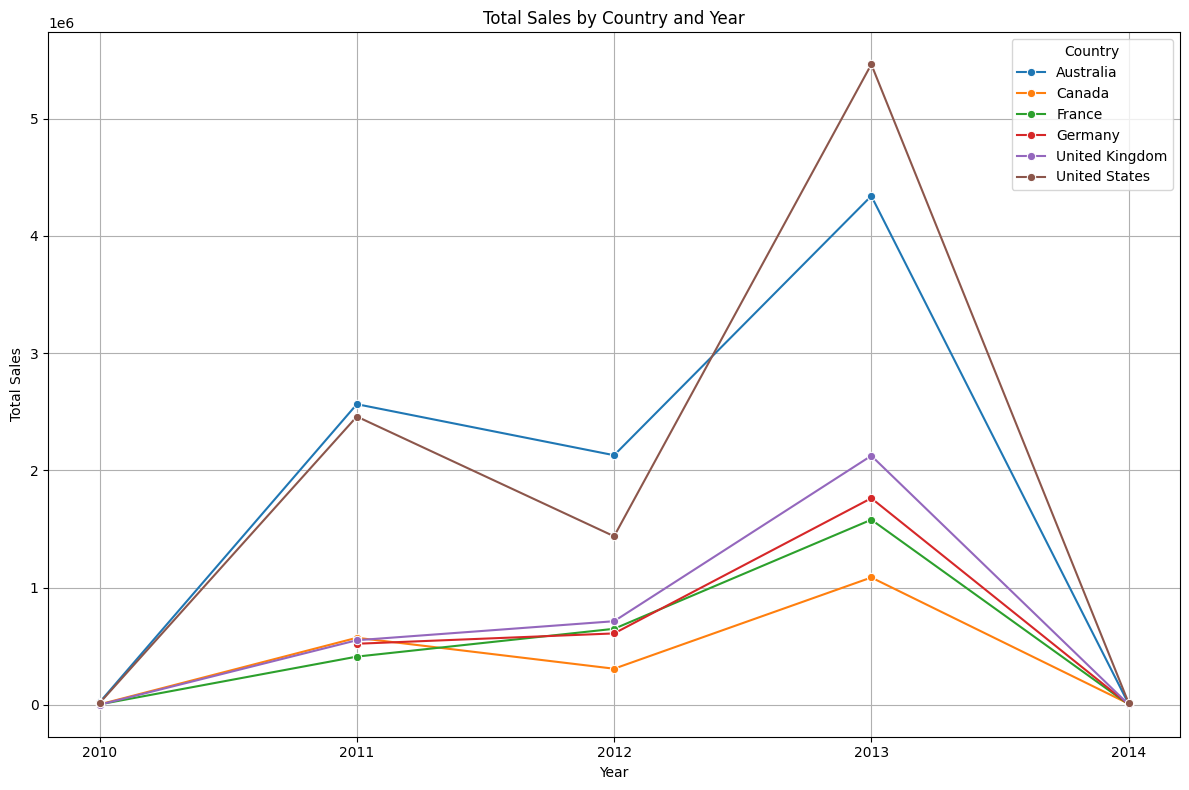

In [73]:
plt.figure(figsize=(12, 8))
sns.lineplot(data=total_sales_by_country_year, x='OrderYear', y='TotalSales', hue='EnglishCountryRegionName', marker='o')
plt.title('Total Sales by Country and Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(sorted(total_sales_by_country_year['OrderYear'].unique()))
plt.legend(title='Country')
plt.grid(True)
plt.tight_layout()
plt.show()

In [74]:
# Group by Country Region and Gender and calculate the summary statistics for Yearly Income
income_stats_by_country_gender = df.groupby(['EnglishCountryRegionName', 'Gender'])['YearlyIncome'].agg(['min', 'max', 'std']).reset_index()

# Display the results
display(income_stats_by_country_gender)

,EnglishCountryRegionName,Gender,min,max,std
0,Australia,F,10000,160000,30613.956169
1,Australia,M,10000,170000,32550.778171
2,Canada,F,10000,170000,19435.158438
3,Canada,M,10000,170000,22702.851581
4,France,F,10000,110000,28421.836245
5,France,M,10000,110000,28665.660622
6,Germany,F,10000,130000,37622.814569
7,Germany,M,10000,130000,37487.619366
8,United Kingdom,F,10000,170000,51130.689140
9,United Kingdom,M,10000,170000,50963.707551


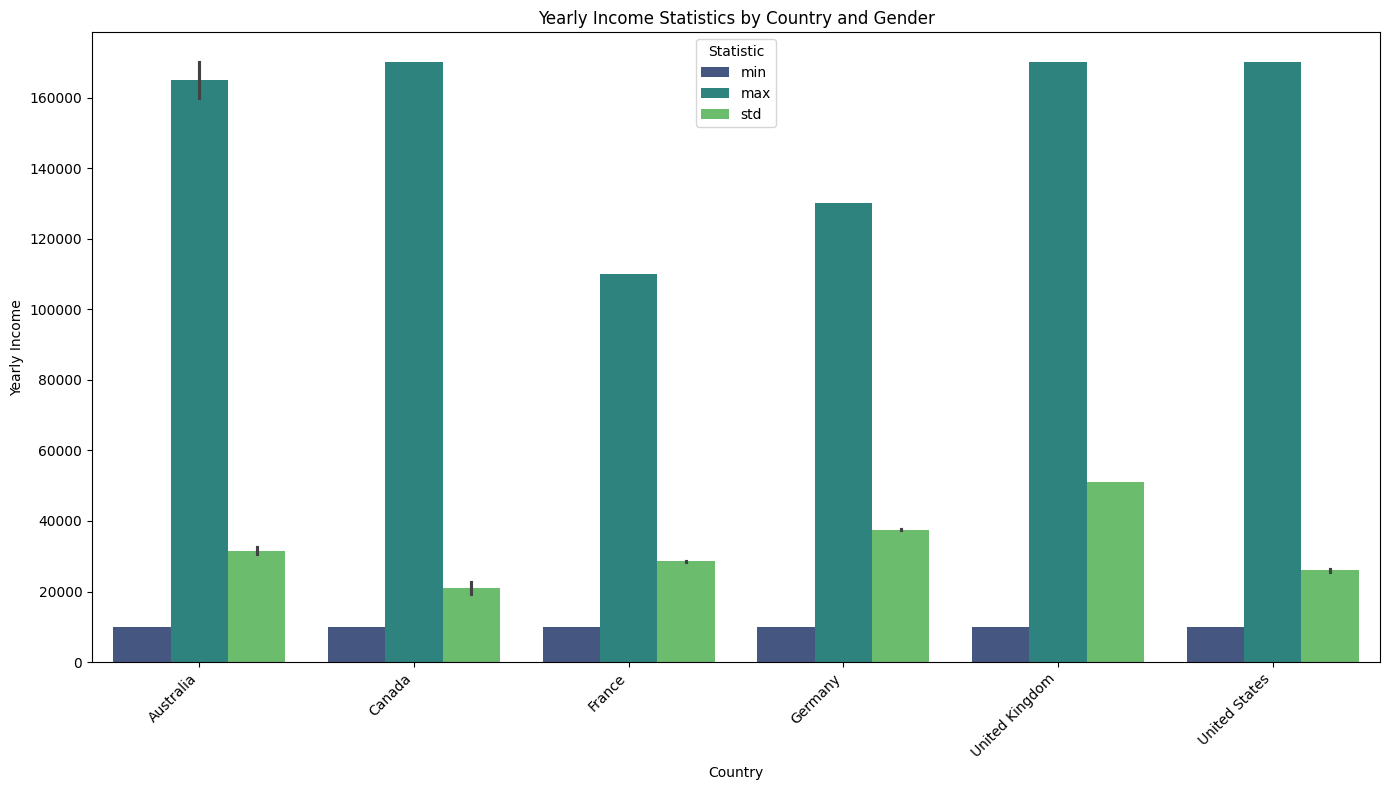

In [75]:
income_stats_melted = income_stats_by_country_gender.melt(id_vars=['EnglishCountryRegionName', 'Gender'],
                                                           value_vars=['min', 'max', 'std'],
                                                           var_name='Statistic', value_name='YearlyIncome')

# Create a grouped bar plot
plt.figure(figsize=(14, 8))
sns.barplot(data=income_stats_melted, x='EnglishCountryRegionName', y='YearlyIncome', hue='Statistic', palette='viridis')
plt.title('Yearly Income Statistics by Country and Gender')
plt.xlabel('Country')
plt.ylabel('Yearly Income')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Statistic')
plt.tight_layout()
plt.show()

In [76]:
# Group by product name and calculate total sales and average unit price
product_sales_price = df.groupby('EnglishProductName').agg(
    TotalSales=('SalesAmount', 'sum'),
    AverageUnitPrice=('UnitPrice', 'mean')
).reset_index()

# Identify the product with the highest total sales
top_selling_product = product_sales_price.loc[product_sales_price['TotalSales'].idxmax()]

# Display the product category with the highest total sales and its average unit price
print("Product Category with the Highest Total Sales:")
print(top_selling_product[['EnglishProductName', 'AverageUnitPrice']])

Product Category with the Highest Total Sales:
EnglishProductName    Mountain-200 Black, 46
AverageUnitPrice                 2215.273465
Name: 34, dtype: object


In [77]:
# Group by HouseOwnerFlag and calculate the total sales
sales_by_homeownership = df.groupby('HouseOwnerFlag')['SalesAmount'].sum().reset_index()

# Rename the columns for clarity
sales_by_homeownership = sales_by_homeownership.rename(columns={'SalesAmount': 'TotalSales'})

# Display the results
display(sales_by_homeownership)

,HouseOwnerFlag,TotalSales
0,0,8.973327e+06
1,1,2.038535e+07


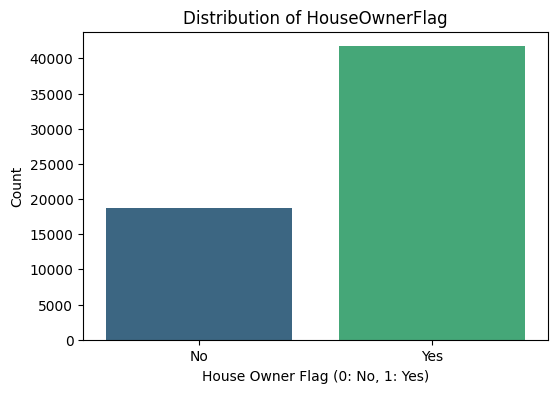

In [78]:
# Visualize the distribution of HouseOwnerFlag
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='HouseOwnerFlag', hue='HouseOwnerFlag', palette='viridis', legend=False)
plt.title('Distribution of HouseOwnerFlag')
plt.xlabel('House Owner Flag (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

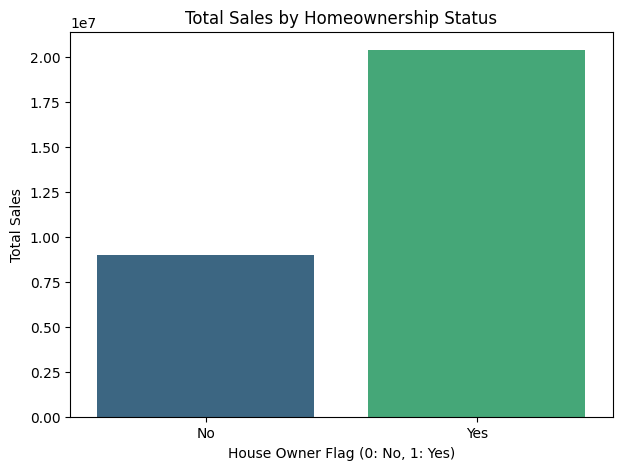

In [79]:
# Visualize the total sales by HouseOwnerFlag
plt.figure(figsize=(7, 5))
sns.barplot(data=sales_by_homeownership, x='HouseOwnerFlag', y='TotalSales', hue='HouseOwnerFlag', palette='viridis', legend=False)
plt.title('Total Sales by Homeownership Status')
plt.xlabel('House Owner Flag (0: No, 1: Yes)')
plt.ylabel('Total Sales')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

In [80]:

sales_homeowners = df[df['HouseOwnerFlag'] == 1]['SalesAmount']
sales_non_homeowners = df[df['HouseOwnerFlag'] == 0]['SalesAmount']
ttest_result = stats.ttest_ind(sales_homeowners, sales_non_homeowners)

print("Independent Samples T-Test Results:")
print(f"  Test Statistic: {ttest_result.statistic:.4f}")
print(f"  P-value: {ttest_result.pvalue:.4f}")

alpha = 0.05  # Significance level
if ttest_result.pvalue < alpha:
    print("\nConclusion: There is a statistically significant difference in sales amount between homeowners and non-homeowners.")
else:
    print("\nConclusion: There is no statistically significant difference in sales amount between homeowners and non-homeowners.")

Independent Samples T-Test Results:
  Test Statistic: 1.0997
  P-value: 0.2715

Conclusion: There is no statistically significant difference in sales amount between homeowners and non-homeowners.
